Text(0.5, 1.0, 'Gráfico')

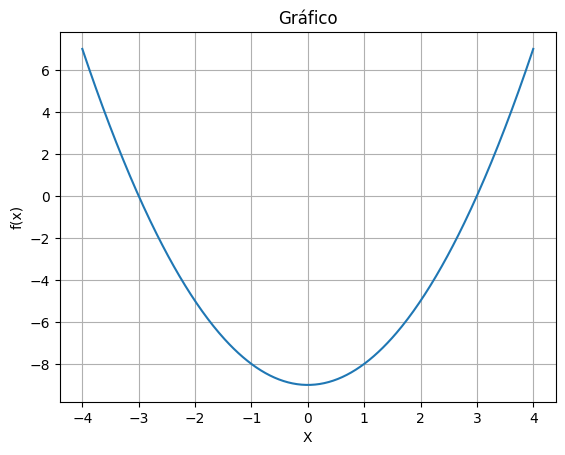

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
sp.init_printing()
%matplotlib inline

lista_simbolos = ['x','y']
x,y = sp.symbols(lista_simbolos)
f,df = sp.symbols('f df', cls=sp.Function)
f =  x**2 - 9
df = sp.diff(f,x)

xmin = -4
xmax = 4
intervalo = np.linspace(xmin,xmax,400)
y = []
for i in range(len(intervalo)):
    y.append(f.subs(x,intervalo[i]))
    
ax = plt.subplots()
ax= plt.plot(intervalo,y)
plt.grid()
plt.xlabel('X')
plt.ylabel('f(x)')
plt.title('Gráfico')

In [2]:
def newton_method(x0,tol,max_iter):
    import matplotlib.pyplot as plt
    %matplotlib widget

    iteracoes = [0]
    pontos_x =[x0]
    pontos_y =[f.subs(x,x0)]
    for i in range(max_iter):
        iteracoes.append(i)
        pontos_y.append(f.subs(x,pontos_x[i]))
        x1 = pontos_x[i] - f.subs(x,pontos_x[i])/df.subs(x,pontos_x[i])
        pontos_x.append(x1)
        if abs(x1-pontos_x[i]) < tol:
            erro = f.subs(x,x1)
            break
        elif abs(x1-pontos_x[i])>tol and i==max_iter:
            print("O método de Newton não convergiu dentro do número máximo de iterações")
            return None
            input("Pressione Enter para sair...")
            sys.exit()
            
    print('A raiz da função é: {:.4f}'.format(x1))
    print('O número de iterações é:',i)
    print('O erro absoluto é:{:.8f}'.format(erro))
    print('ptx', pontos_x)
    print('pty', pontos_y)
    fig, (ax1,ax2)=plt.subplots(2,1)
    ax1.plot(iteracoes,pontos_y,)
    ax1.xlabel='Número de iterações'
    ax1.ylabel='F(x)'
    ax2.plot(intervalo,y, label='função')
    ax2.xlabel='X'
    ax2.ylabel='f(x)'
    ax2.scatter(x1,f.subs(x,x1),color='red',label='raiz')
    ax1.grid(True)
    ax2.grid(True)

A raiz da função é: 3.0000
O número de iterações é: 4
O erro absoluto é:0.00000000
ptx [2, 13/4, 313/104, 195313/65104, 76293945313/25431315104, 11641532182693481445313/3880510727564493815104]
pty [-5, -5, 25/16, 625/10816, 390625/4238530816, 152587890625/646751787918938530816]


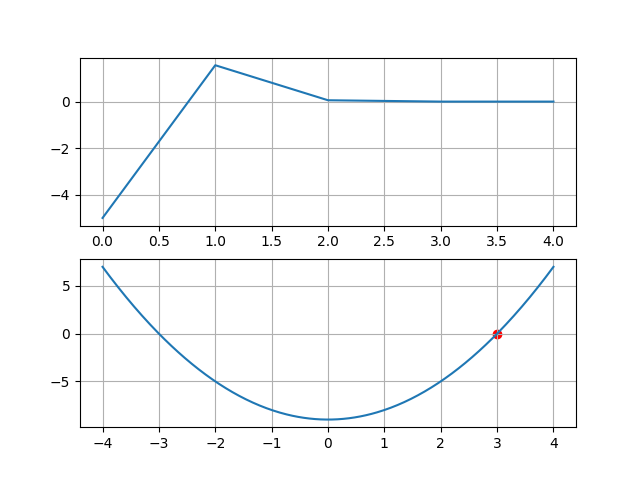

In [3]:
newton_method(2,1e-10,1000)

In [4]:
newton_method(0,1e-10,1000)

TypeError: Invalid NaN comparison

Uma vez que a derivada no ponto é zero, o quociente f/df fica indefinido.